# Hierarchical Clustering with Evaluation Metrics

This notebook demonstrates how to:
1. Generate synthetic data for clustering
2. Apply Hierarchical clustering algorithm
3. Evaluate clustering performance using three metrics:
   - Silhouette Score
   - Calinski-Harabasz Index
   - Davies-Bouldin Index
4. Visualize the clustering results and find the optimal number of clusters

In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.preprocessing import StandardScaler
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage
from mpl_toolkits.mplot3d import Axes3D
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

## 1. Generate Synthetic Data

We'll create a synthetic dataset with a known number of clusters to demonstrate Hierarchical clustering.

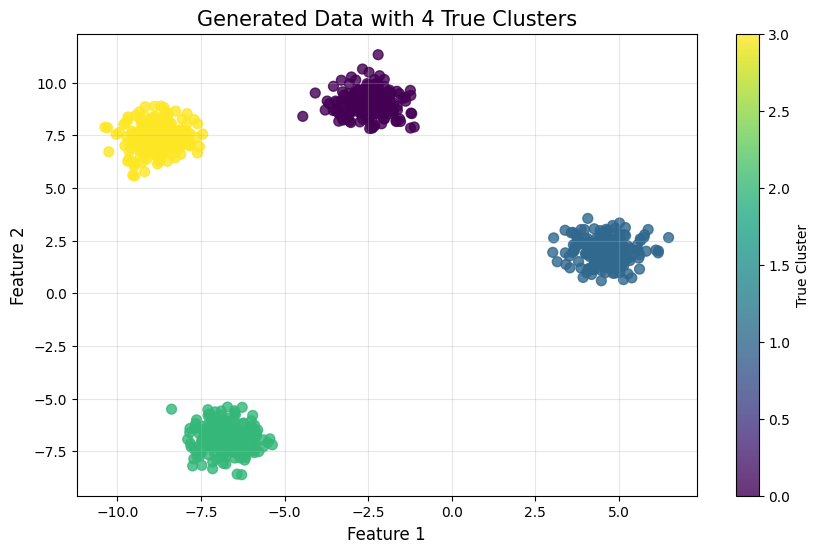

In [2]:
# Generate synthetic data with 4 true clusters
X, y_true = make_blobs(n_samples=800, centers=4, cluster_std=0.60, random_state=42)

# Plot the generated data
plt.figure(figsize=(10, 6))
plt.scatter(X[:, 0], X[:, 1], c=y_true, cmap='viridis', alpha=0.8, s=50)
plt.title('Generated Data with 4 True Clusters', fontsize=15)
plt.xlabel('Feature 1', fontsize=12)
plt.ylabel('Feature 2', fontsize=12)
plt.colorbar(label='True Cluster')
plt.grid(alpha=0.3)
plt.show()

## 2. Visualize Hierarchical Structure with Dendrogram

A dendrogram is a diagram that shows the hierarchical relationship between objects. It is most commonly created as an output from hierarchical clustering.

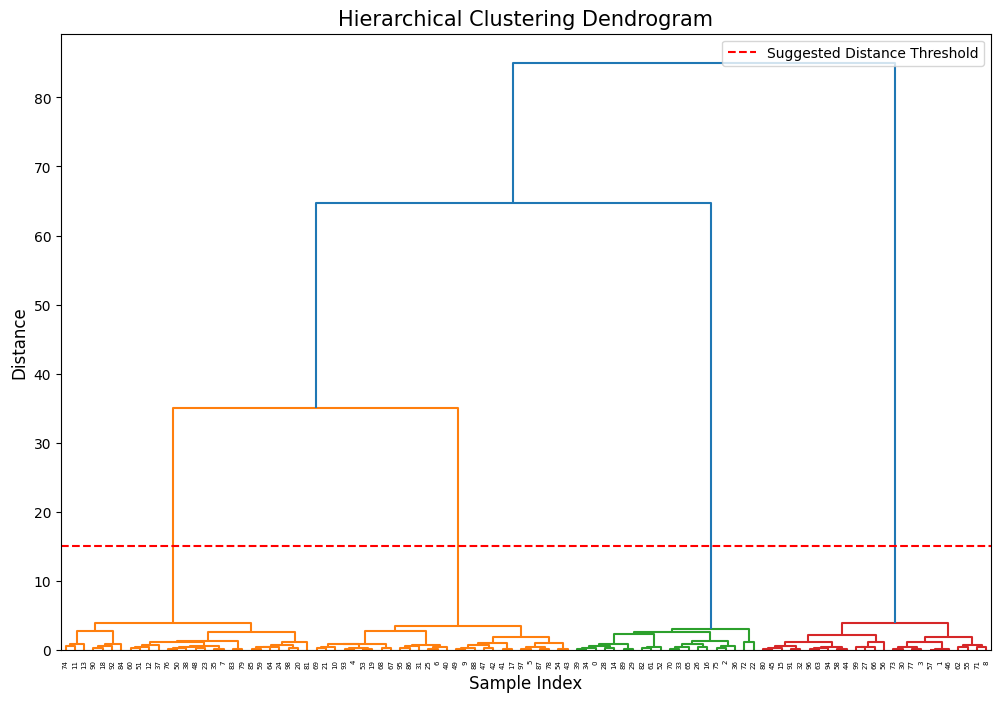

In [ ]:
# Create a sample of the data for the dendrogram (as dendrograms become unwieldy with large datasets)
np.random.seed(42)
indices = np.random.choice(range(len(X)), size=100, replace=False)
X_sample = X[indices]

# Create linkage matrix using Ward's method
linked = linkage(X_sample, method='ward')

# Plot the dendrogram
plt.figure(figsize=(12, 8))
dendrogram(linked,
           orientation='top',
           distance_sort='descending',
           show_leaf_counts=True)
plt.title('Hierarchical Clustering Dendrogram', fontsize=15)
plt.xlabel('Sample Index', fontsize=12)
plt.ylabel('Distance', fontsize=12)
plt.legend()
plt.show()

## 3. Apply Hierarchical Clustering

Now, let's apply hierarchical clustering to our synthetic data. We'll try different numbers of clusters to see which one best fits the data.

In [4]:
# Function to perform hierarchical clustering and evaluate metrics
def perform_hierarchical(X, n_clusters, linkage='ward'):
    hc = AgglomerativeClustering(n_clusters=n_clusters, linkage=linkage)
    clusters = hc.fit_predict(X)
    
    # Calculate evaluation metrics
    silhouette = silhouette_score(X, clusters)
    calinski = calinski_harabasz_score(X, clusters)
    davies = davies_bouldin_score(X, clusters)
    
    return clusters, silhouette, calinski, davies

In [5]:
# Try different numbers of clusters with different linkage methods
cluster_range = range(2, 11)
linkage_methods = ['ward', 'complete', 'average', 'single']
all_results = []

for linkage_method in linkage_methods:
    results = []
    for n_clusters in cluster_range:
        clusters, silhouette, calinski, davies = perform_hierarchical(X, n_clusters, linkage_method)
        results.append({
            'n_clusters': n_clusters,
            'linkage': linkage_method,
            'silhouette': silhouette,
            'calinski_harabasz': calinski,
            'davies_bouldin': davies
        })
    all_results.extend(results)

# Convert results to DataFrame
results_df = pd.DataFrame(all_results)
results_df.sort_values(['linkage', 'n_clusters'], inplace=True)
results_df

,n_clusters,linkage,silhouette,calinski_harabasz,davies_bouldin
18,2,average,0.614916,934.066368,0.485617
19,3,average,0.796813,3917.000548,0.315867
20,4,average,0.874185,24294.487290,0.176767
21,5,average,0.764354,18342.741543,0.260197
22,6,average,0.651043,14821.798691,0.430570
23,7,average,0.609170,12485.431139,0.443141
24,8,average,0.570010,10813.364265,0.440490
25,9,average,0.465419,9865.494588,0.517333
26,10,average,0.445965,9024.864890,0.556969
9,2,complete,0.614916,934.066368,0.485617


## 4. Evaluate Clustering Performance

Let's understand what each evaluation metric means:

1. **Silhouette Score**: Measures how similar an object is to its own cluster compared to other clusters. Range from -1 to 1, where higher values indicate better clustering.

2. **Calinski-Harabasz Index**: Ratio of between-cluster variance to within-cluster variance. Higher values indicate better defined clusters.

3. **Davies-Bouldin Index**: Average similarity between each cluster and its most similar cluster. Lower values indicate better clustering.

Now, let's visualize these metrics to determine the optimal number of clusters and linkage method.

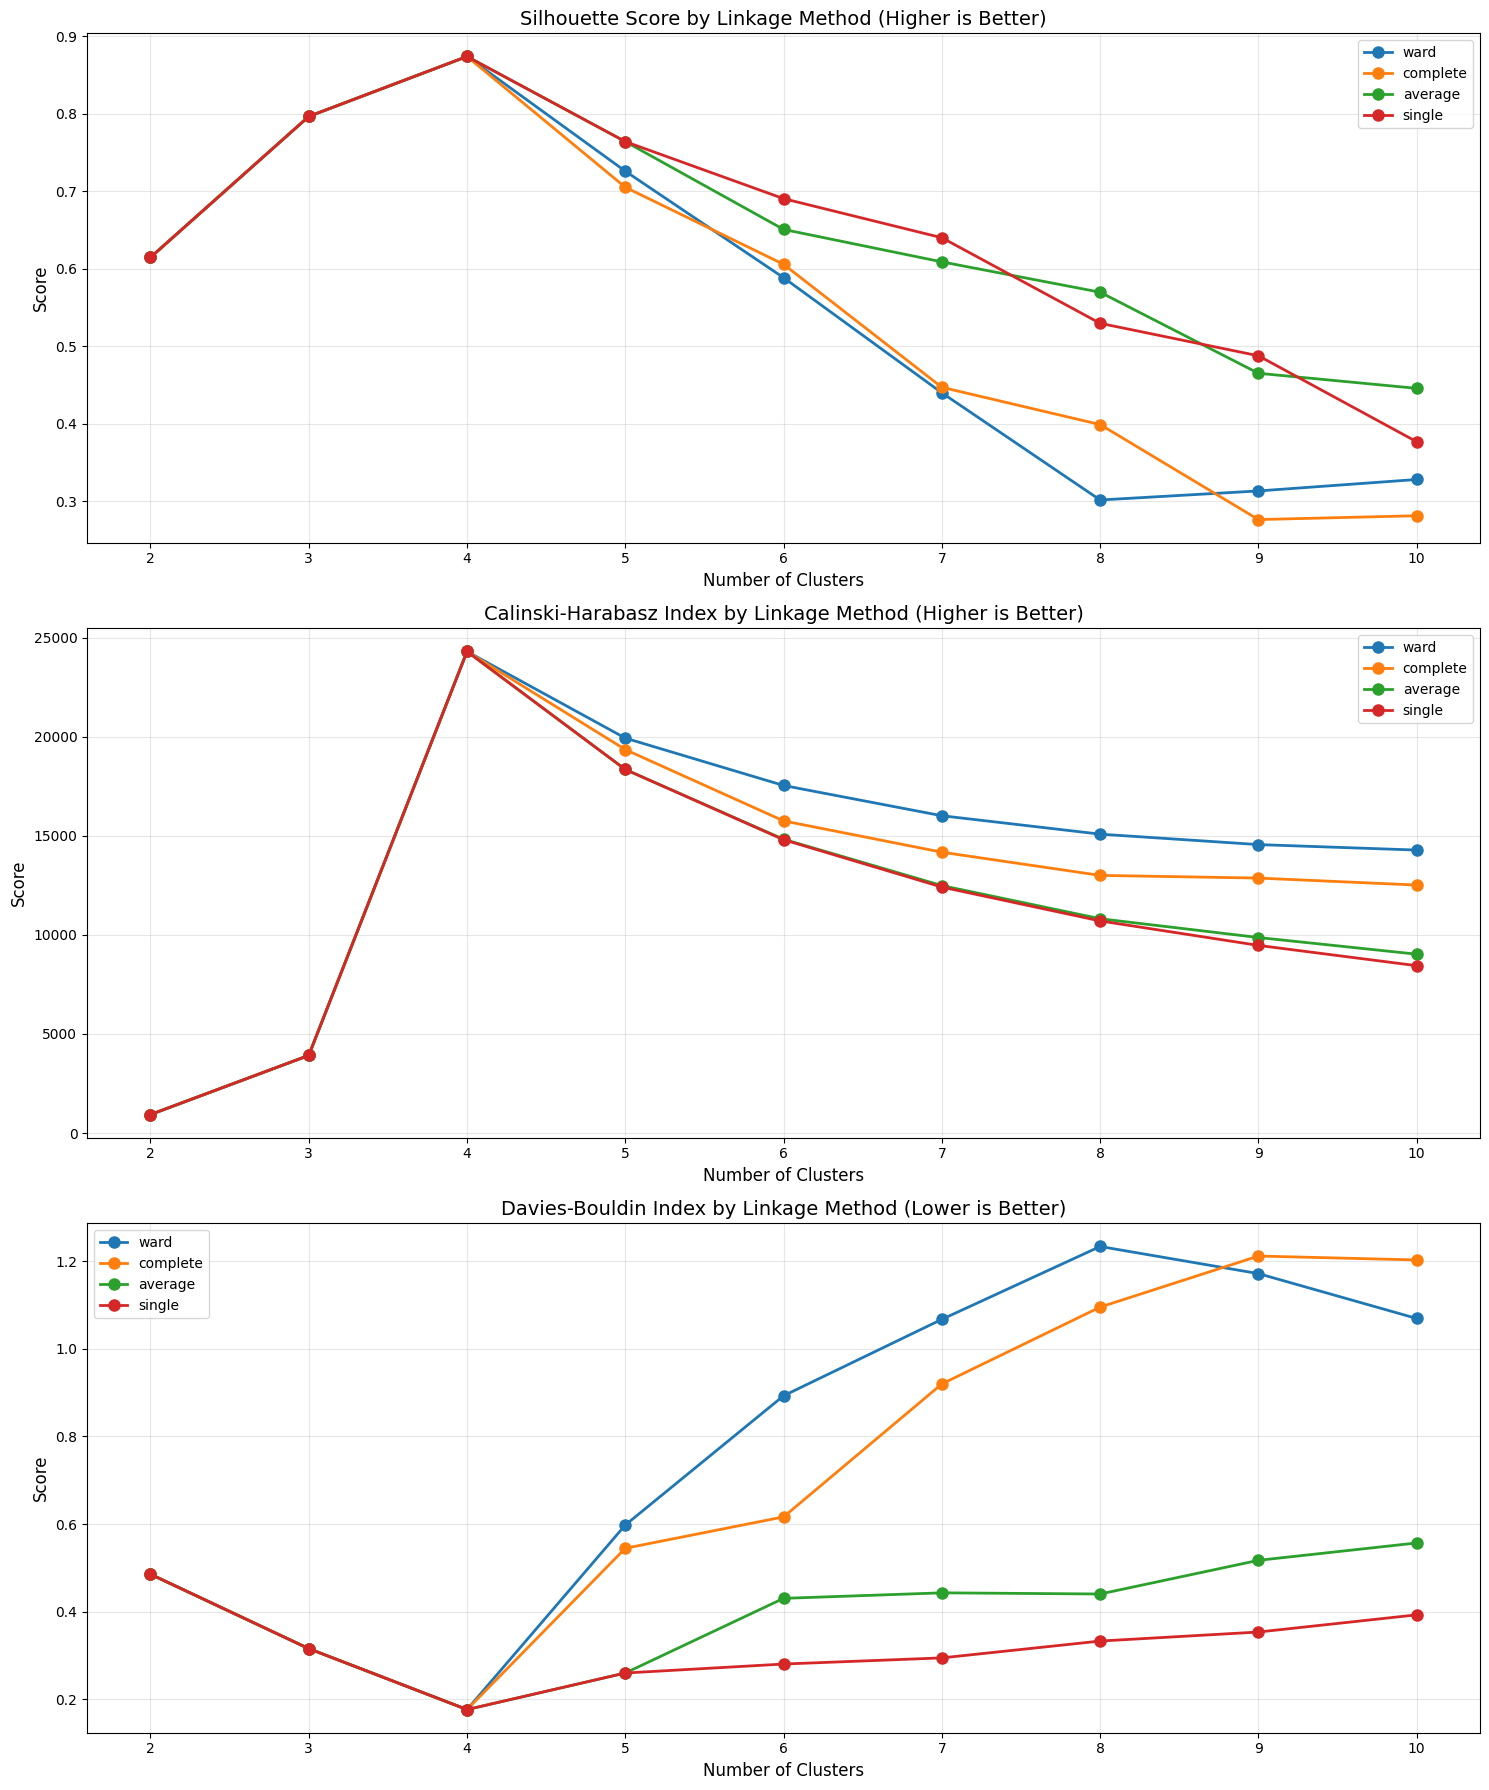

In [6]:
# Create a 2x2 grid for our evaluation metrics
fig, axes = plt.subplots(3, 1, figsize=(15, 18))

# Silhouette Score (higher is better)
for method in linkage_methods:
    method_df = results_df[results_df['linkage'] == method]
    axes[0].plot(method_df['n_clusters'], method_df['silhouette'], 'o-', linewidth=2, markersize=8, label=method)
axes[0].set_title('Silhouette Score by Linkage Method (Higher is Better)', fontsize=14)
axes[0].set_xlabel('Number of Clusters', fontsize=12)
axes[0].set_ylabel('Score', fontsize=12)
axes[0].grid(alpha=0.3)
axes[0].legend()

# Calinski-Harabasz Index (higher is better)
for method in linkage_methods:
    method_df = results_df[results_df['linkage'] == method]
    axes[1].plot(method_df['n_clusters'], method_df['calinski_harabasz'], 'o-', linewidth=2, markersize=8, label=method)
axes[1].set_title('Calinski-Harabasz Index by Linkage Method (Higher is Better)', fontsize=14)
axes[1].set_xlabel('Number of Clusters', fontsize=12)
axes[1].set_ylabel('Score', fontsize=12)
axes[1].grid(alpha=0.3)
axes[1].legend()

# Davies-Bouldin Index (lower is better)
for method in linkage_methods:
    method_df = results_df[results_df['linkage'] == method]
    axes[2].plot(method_df['n_clusters'], method_df['davies_bouldin'], 'o-', linewidth=2, markersize=8, label=method)
axes[2].set_title('Davies-Bouldin Index by Linkage Method (Lower is Better)', fontsize=14)
axes[2].set_xlabel('Number of Clusters', fontsize=12)
axes[2].set_ylabel('Score', fontsize=12)
axes[2].grid(alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.show()

In [7]:
# Find optimal parameters based on metrics
best_silhouette = results_df.loc[results_df['silhouette'].idxmax()]
best_calinski = results_df.loc[results_df['calinski_harabasz'].idxmax()]
best_davies = results_df.loc[results_df['davies_bouldin'].idxmin()]

print("Best parameters according to different metrics:")
print(f"Silhouette Score suggests {best_silhouette['n_clusters']} clusters with {best_silhouette['linkage']} linkage")
print(f"Calinski-Harabasz Index suggests {best_calinski['n_clusters']} clusters with {best_calinski['linkage']} linkage")
print(f"Davies-Bouldin Index suggests {best_davies['n_clusters']} clusters with {best_davies['linkage']} linkage")

Best parameters according to different metrics:
Silhouette Score suggests 4 clusters with average linkage
Calinski-Harabasz Index suggests 4 clusters with ward linkage
Davies-Bouldin Index suggests 4 clusters with average linkage


## 5. Visualize the Clustering Results

Now, let's visualize the clustering results for the optimal number of clusters and linkage method.

In [8]:
# Determine the most frequent optimal number of clusters
optimal_suggestions = [
    (best_silhouette['n_clusters'], best_silhouette['linkage']),
    (best_calinski['n_clusters'], best_calinski['linkage']),
    (best_davies['n_clusters'], best_davies['linkage'])
]
from collections import Counter
counter = Counter(optimal_suggestions)
optimal_k, optimal_linkage = counter.most_common(1)[0][0]

print(f"Based on majority voting, the optimal parameters are: {optimal_k} clusters with {optimal_linkage} linkage")

# If no clear majority, use the parameters from the silhouette score
if counter.most_common(1)[0][1] == 1:
    optimal_k, optimal_linkage = best_silhouette['n_clusters'], best_silhouette['linkage']
    print(f"No clear majority, defaulting to silhouette score suggestion: {optimal_k} clusters with {optimal_linkage} linkage")

Based on majority voting, the optimal parameters are: 4 clusters with average linkage


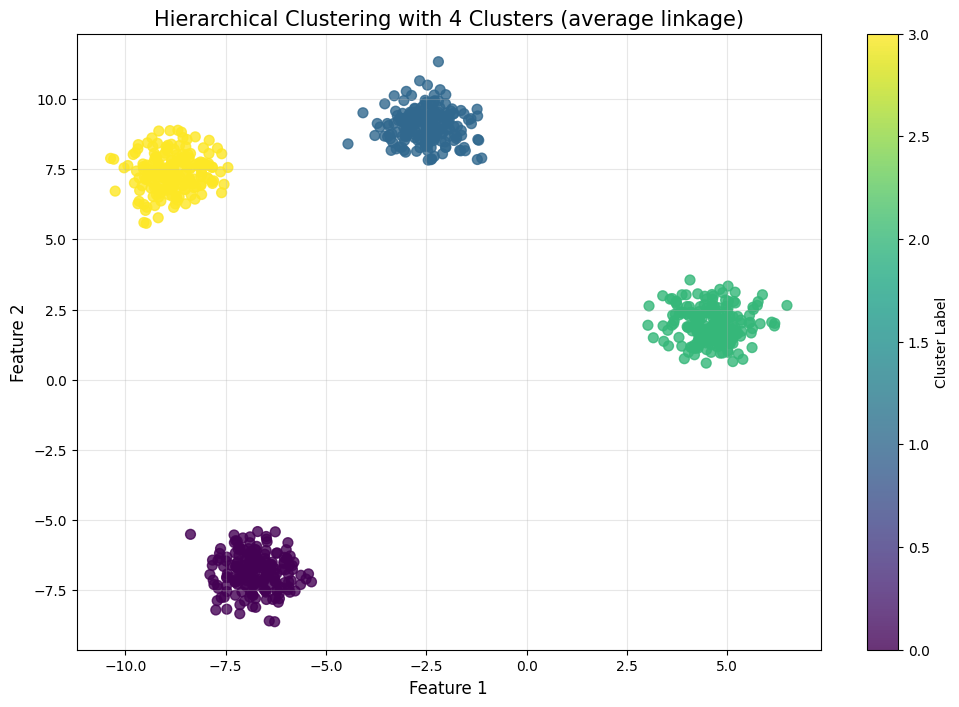

In [9]:
# Perform hierarchical clustering with the optimal parameters
hc = AgglomerativeClustering(n_clusters=optimal_k, linkage=optimal_linkage)
cluster_labels = hc.fit_predict(X)

# Plot the clusters
plt.figure(figsize=(12, 8))

# Plot data points with their assigned clusters
scatter = plt.scatter(X[:, 0], X[:, 1], c=cluster_labels, cmap='viridis', alpha=0.8, s=50)

plt.title(f'Hierarchical Clustering with {optimal_k} Clusters ({optimal_linkage} linkage)', fontsize=15)
plt.xlabel('Feature 1', fontsize=12)
plt.ylabel('Feature 2', fontsize=12)
plt.grid(alpha=0.3)
plt.colorbar(scatter, label='Cluster Label')
plt.show()

## 6. Comparing True Labels with Clustering Results

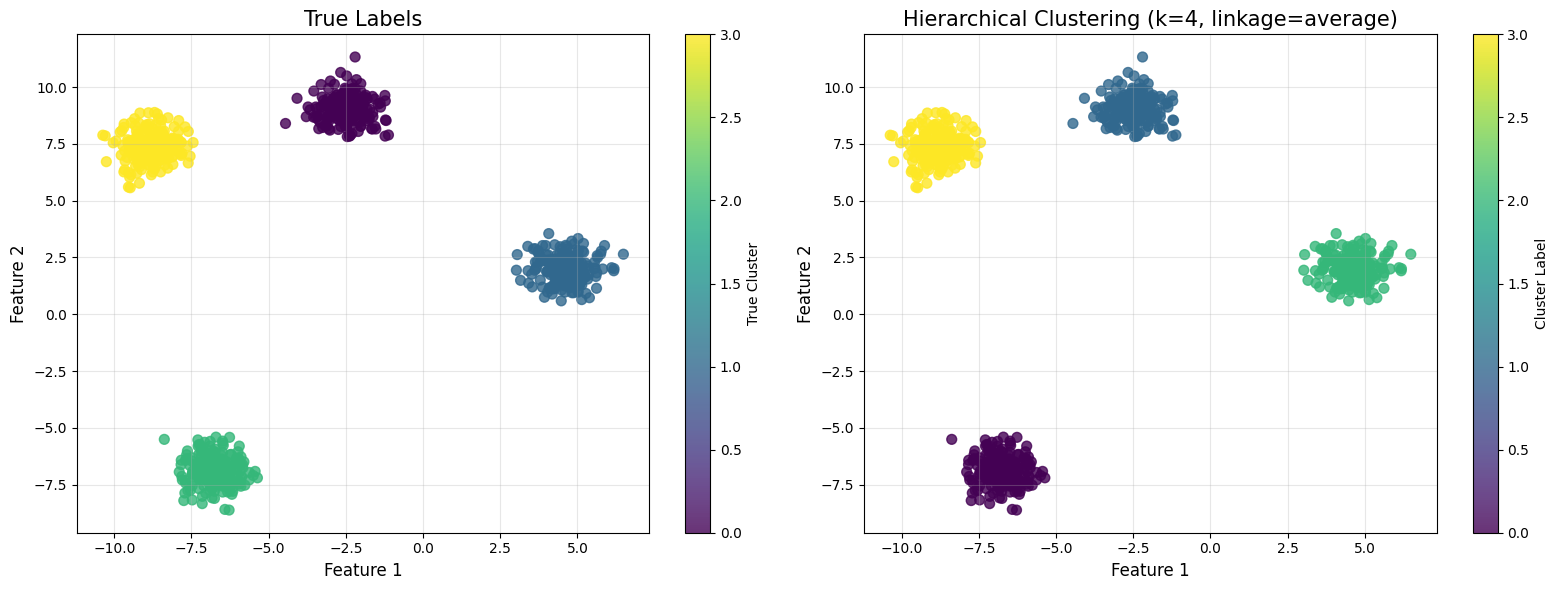

In [10]:
# Compare true labels with hierarchical clustering results
plt.figure(figsize=(16, 6))

# True labels
plt.subplot(1, 2, 1)
plt.scatter(X[:, 0], X[:, 1], c=y_true, cmap='viridis', alpha=0.8, s=50)
plt.title('True Labels', fontsize=15)
plt.xlabel('Feature 1', fontsize=12)
plt.ylabel('Feature 2', fontsize=12)
plt.grid(alpha=0.3)
plt.colorbar(label='True Cluster')

# Hierarchical clustering prediction
plt.subplot(1, 2, 2)
scatter = plt.scatter(X[:, 0], X[:, 1], c=cluster_labels, cmap='viridis', alpha=0.8, s=50)
plt.title(f'Hierarchical Clustering (k={optimal_k}, linkage={optimal_linkage})', fontsize=15)
plt.xlabel('Feature 1', fontsize=12)
plt.ylabel('Feature 2', fontsize=12)
plt.grid(alpha=0.3)
plt.colorbar(scatter, label='Cluster Label')

plt.tight_layout()
plt.show()

## 7. Create a More Complex Dataset

Let's create more complex datasets to test how hierarchical clustering performs on non-spherical data.

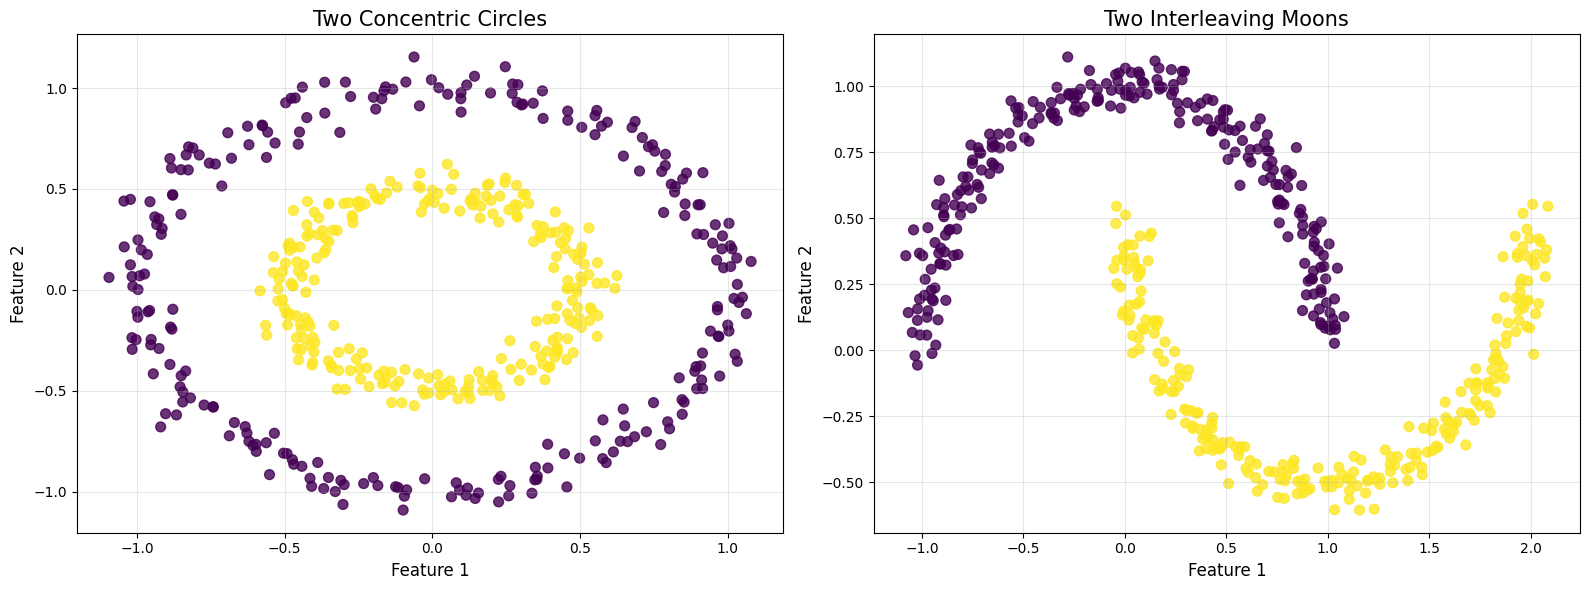

In [11]:
# Generate a more complex dataset
from sklearn.datasets import make_moons, make_circles

# Generate two interleaving half circles
X_circles, y_circles = make_circles(n_samples=500, noise=0.05, factor=0.5, random_state=42)

# Generate two interleaving moons
X_moons, y_moons = make_moons(n_samples=500, noise=0.05, random_state=42)

# Plot the complex datasets
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(X_circles[:, 0], X_circles[:, 1], c=y_circles, cmap='viridis', alpha=0.8, s=50)
axes[0].set_title('Two Concentric Circles', fontsize=15)
axes[0].set_xlabel('Feature 1', fontsize=12)
axes[0].set_ylabel('Feature 2', fontsize=12)
axes[0].grid(alpha=0.3)

axes[1].scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons, cmap='viridis', alpha=0.8, s=50)
axes[1].set_title('Two Interleaving Moons', fontsize=15)
axes[1].set_xlabel('Feature 1', fontsize=12)
axes[1].set_ylabel('Feature 2', fontsize=12)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Apply Hierarchical Clustering to Complex Datasets

Let's test how different linkage methods perform on these non-spherical datasets.

In [12]:
# Function to evaluate hierarchical clustering on a dataset
def evaluate_hierarchical(X, true_labels, linkage_methods=['ward', 'complete', 'average', 'single'], n_clusters=2):
    results = []
    
    # Test each linkage method
    fig, axes = plt.subplots(len(linkage_methods), 1, figsize=(12, 5*len(linkage_methods)))
    
    for i, method in enumerate(linkage_methods):
        # Apply hierarchical clustering
        hc = AgglomerativeClustering(n_clusters=n_clusters, linkage=method)
        predicted_labels = hc.fit_predict(X)
        
        # Calculate evaluation metrics
        silhouette = silhouette_score(X, predicted_labels)
        calinski = calinski_harabasz_score(X, predicted_labels)
        davies = davies_bouldin_score(X, predicted_labels)
        
        results.append({
            'linkage': method,
            'silhouette': silhouette,
            'calinski_harabasz': calinski,
            'davies_bouldin': davies
        })
        
        # Plot results
        axes[i].scatter(X[:, 0], X[:, 1], c=predicted_labels, cmap='viridis', alpha=0.8, s=50)
        axes[i].set_title(f'{method.capitalize()} Linkage - Silhouette: {silhouette:.4f}, '
                         f'CH: {calinski:.1f}, DB: {davies:.4f}', fontsize=14)
        axes[i].set_xlabel('Feature 1', fontsize=12)
        axes[i].set_ylabel('Feature 2', fontsize=12)
        axes[i].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print best method
    results_df = pd.DataFrame(results)
    best_silhouette = results_df.loc[results_df['silhouette'].idxmax()]
    best_calinski = results_df.loc[results_df['calinski_harabasz'].idxmax()]
    best_davies = results_df.loc[results_df['davies_bouldin'].idxmin()]
    
    print("Best linkage method according to different metrics:")
    print(f"Silhouette Score: {best_silhouette['linkage']} (score: {best_silhouette['silhouette']:.4f})")
    print(f"Calinski-Harabasz: {best_calinski['linkage']} (score: {best_calinski['calinski_harabasz']:.1f})")
    print(f"Davies-Bouldin: {best_davies['linkage']} (score: {best_davies['davies_bouldin']:.4f})")

Evaluation for Circles Dataset:


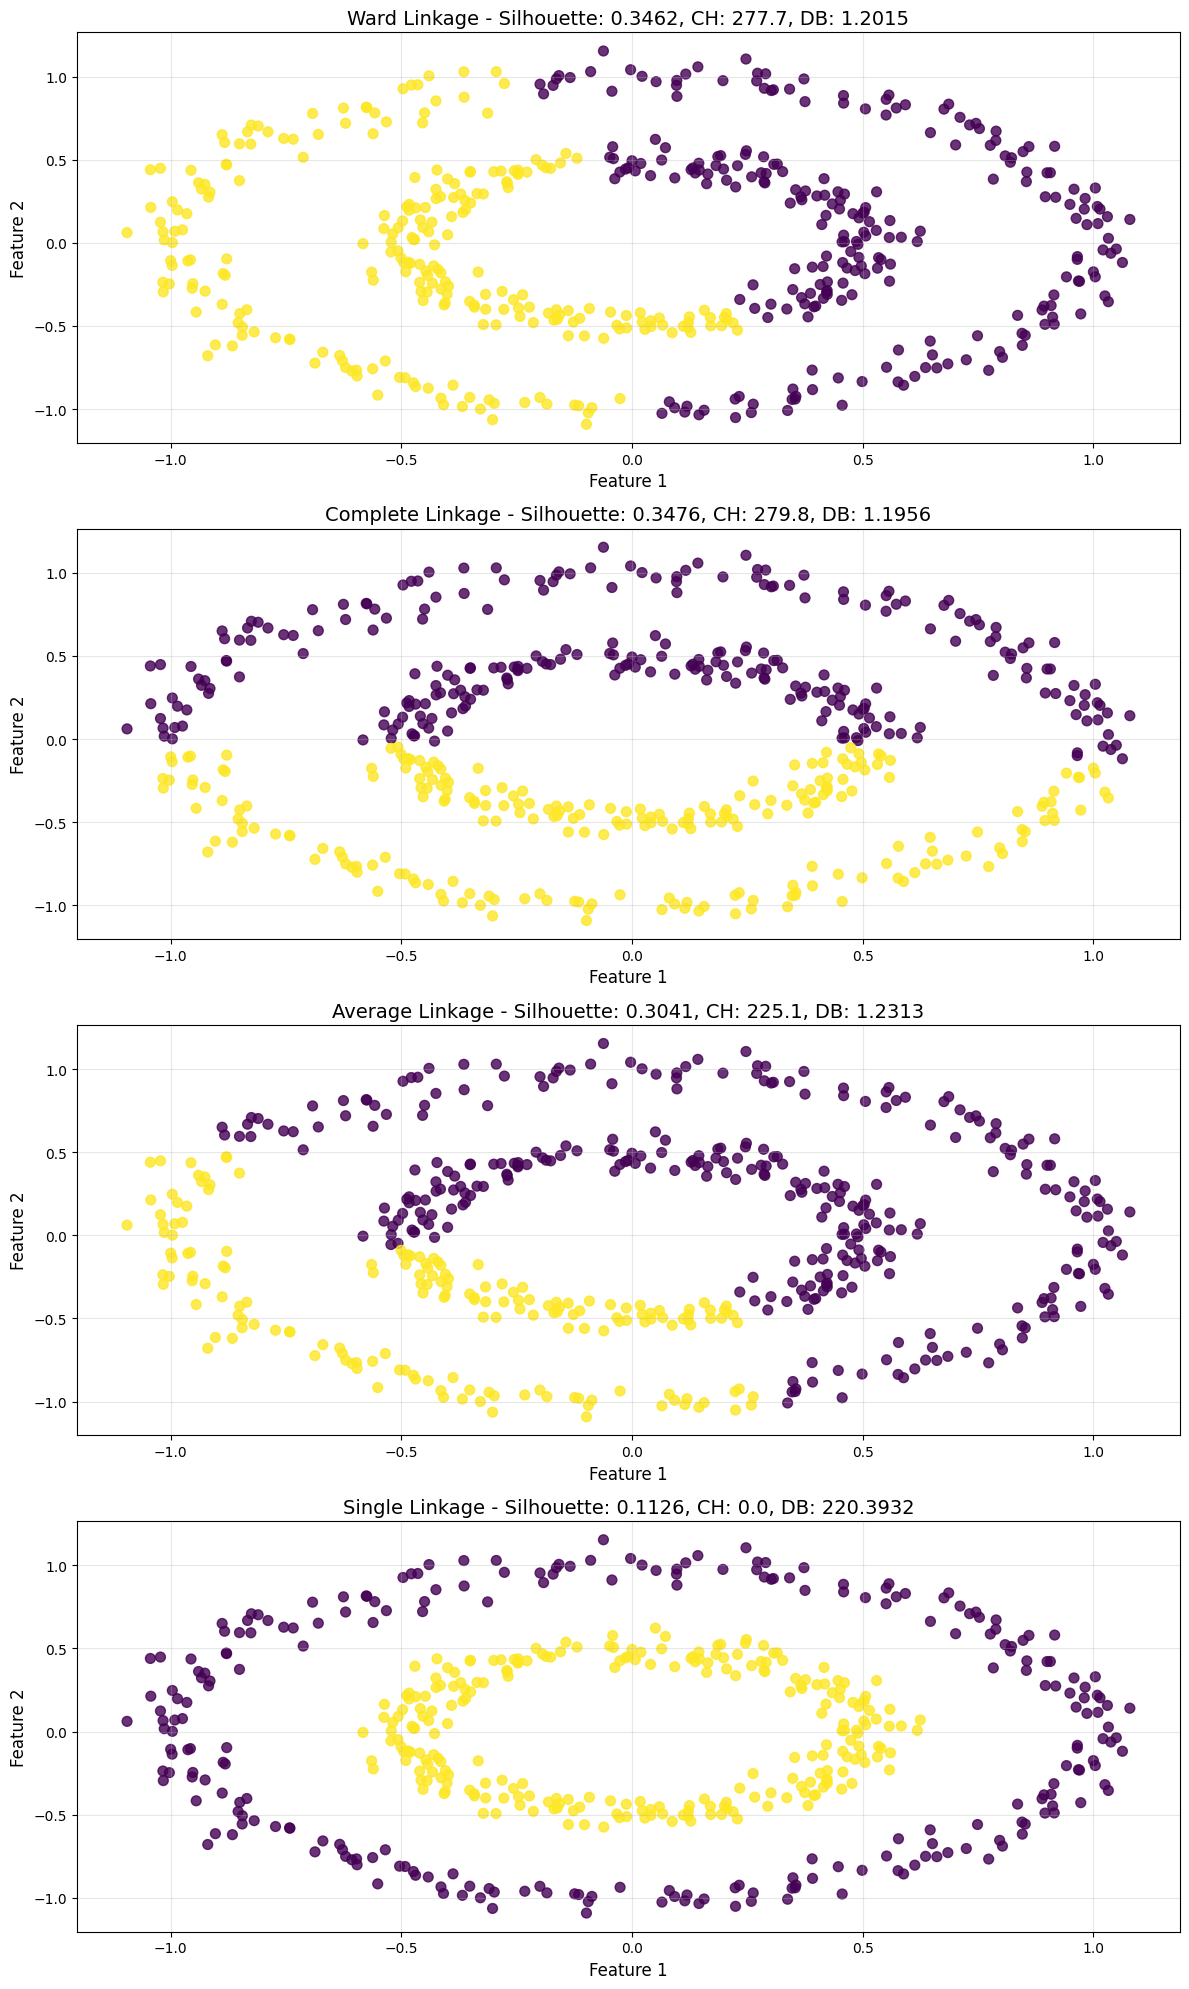

Best linkage method according to different metrics:
Silhouette Score: complete (score: 0.3476)
Calinski-Harabasz: complete (score: 279.8)
Davies-Bouldin: complete (score: 1.1956)


In [13]:
print("Evaluation for Circles Dataset:")
evaluate_hierarchical(X_circles, y_circles)

Evaluation for Moons Dataset:


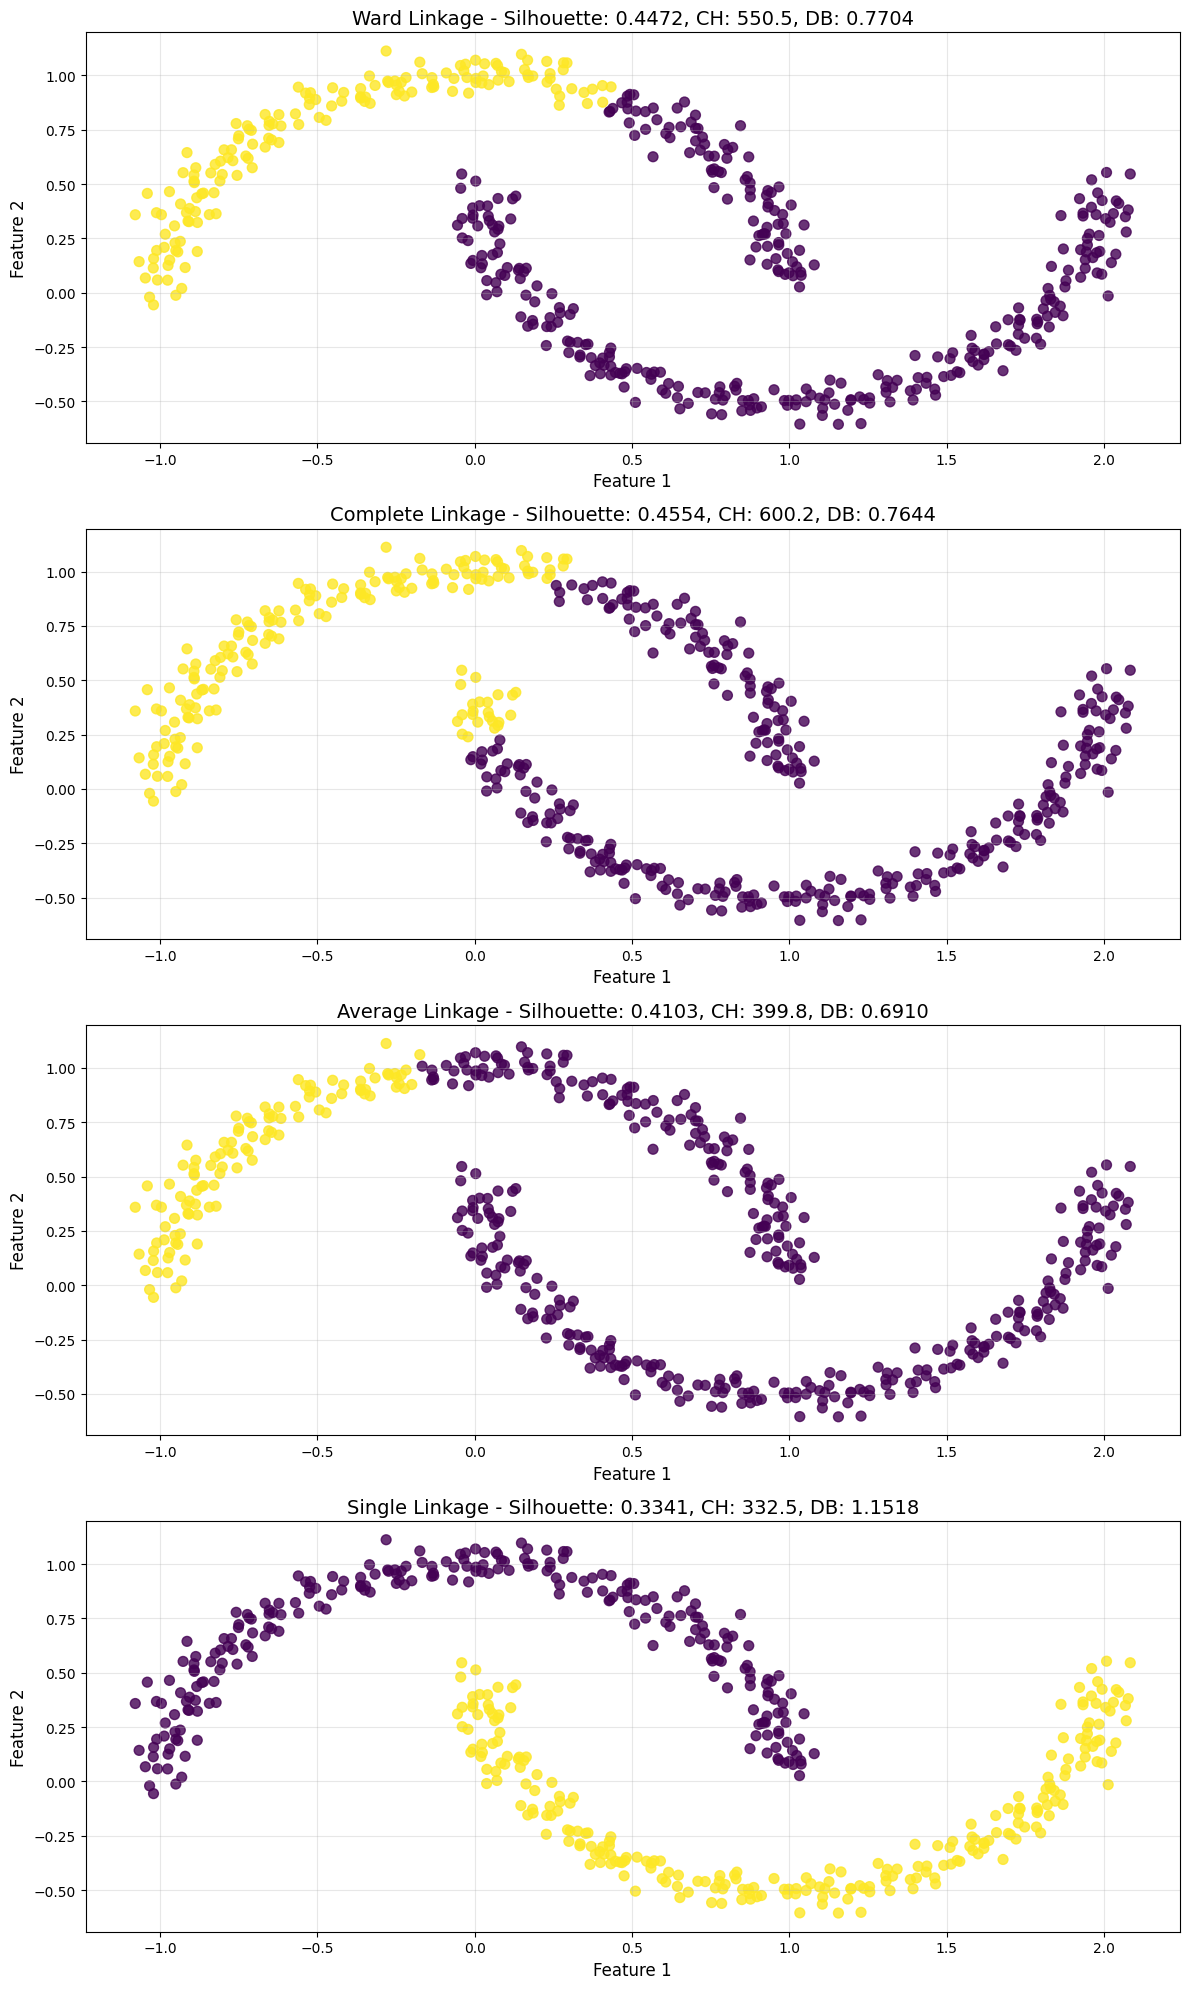

Best linkage method according to different metrics:
Silhouette Score: complete (score: 0.4554)
Calinski-Harabasz: complete (score: 600.2)
Davies-Bouldin: average (score: 0.6910)


In [14]:
print("Evaluation for Moons Dataset:")
evaluate_hierarchical(X_moons, y_moons)

## 8. Conclusion and Key Takeaways

In this notebook, we've demonstrated hierarchical clustering and evaluated its performance using three different metrics:

1. **Silhouette Score**: Measures the quality of clusters by looking at how similar an object is to its own cluster compared to other clusters. Range: [-1, 1], higher is better.

2. **Calinski-Harabasz Index**: Measures the ratio of between-cluster dispersion to within-cluster dispersion. Higher values indicate better defined clusters.

3. **Davies-Bouldin Index**: Measures the average similarity between each cluster and its most similar cluster. Lower values indicate better clustering.

**Key takeaways:**

- Hierarchical clustering provides a tree-like structure (dendrogram) that can help visualize the clustering process
- Different linkage methods (ward, complete, average, single) can produce drastically different results
- Ward's linkage often works well for compact, similarly sized clusters
- Single linkage can sometimes capture non-spherical shapes better, but is sensitive to noise
- Hierarchical clustering can handle datasets of varying shapes better than K-means in some cases
- Like K-means, hierarchical clustering still struggles with complex shapes like concentric circles
- The dendrogram can help determine an appropriate number of clusters
- Evaluation metrics provide objective measures to compare different clustering approaches

When applying hierarchical clustering in real-world scenarios, it's important to:
1. Explore your data first
2. Try different linkage methods
3. Use the dendrogram to guide the selection of the number of clusters
4. Use multiple evaluation metrics
5. Consider domain knowledge when interpreting results

Hierarchical clustering is particularly useful when the number of clusters is not known in advance and when a hierarchical representation of the data is desirable.